# K-Means Project: House grouping system

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

### Step 1: Loading the dataset

In [4]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv"
data = pd.read_csv(url)
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Removing unuseful variables

We are only interested in the Latitude, Longitude and MedInc columns.

In [5]:
data_c = data[["MedInc", "Latitude", "Longitude"]]
data_c.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [6]:
data_c.shape

(20640, 3)

In this case, it's not necessary to split the dataset into training and test; we're going to work with all the data.

### Step 2: Build a K-Means

In [7]:
km = KMeans(n_clusters = 6, n_init = "auto", random_state = 42)
km. fit(data_c)

KMeans(n_clusters=6, random_state=42)

In [8]:
y_pred = km.predict(data_c)
y_pred

array([2, 2, 2, ..., 1, 1, 1], shape=(20640,), dtype=int32)

In [9]:
data_c["Clusters"] = y_pred
data_c.head()

,MedInc,Latitude,Longitude,Clusters
0,8.3252,37.88,-122.23,2
1,8.3014,37.86,-122.22,2
2,7.2574,37.85,-122.24,2
3,5.6431,37.85,-122.25,2
4,3.8462,37.85,-122.25,1


In [10]:
clusters=data_c["Clusters"].value_counts()
pd.DataFrame(clusters)

,count
Clusters,
3,6620
1,4875
0,4162
2,2771
4,1677
5,535


In [11]:
centroids=pd.DataFrame(km.cluster_centers_)
centroids.columns = ["MedInc", "Latitude", "Longitude"]
centroids

,MedInc,Latitude,Longitude
0,5.327977,33.858385,-118.023177
1,2.822327,38.351830,-121.892119
2,5.518715,37.707665,-121.967427
3,2.796852,33.816074,-117.819157
4,2.660862,36.113166,-119.727776
5,10.558591,34.848937,-119.178153


#### Plotting results

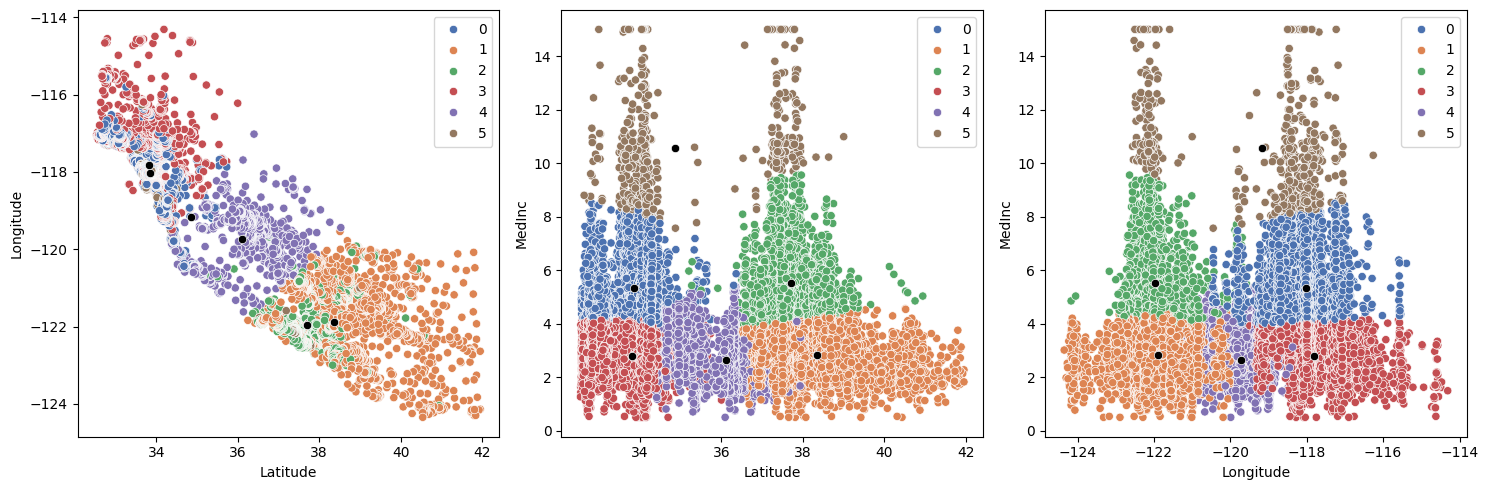

In [12]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = data_c    , x = "Latitude" , y = "Longitude", hue   = "Clusters", palette = "deep")
sns.scatterplot(ax = axis[0], data = centroids , x = "Latitude" , y = "Longitude", color = "black"   , marker  = "o")

sns.scatterplot(ax = axis[1], data = data_c    , x = "Latitude" , y = "MedInc"   , hue   = "Clusters", palette = "deep")
sns.scatterplot(ax = axis[1], data = centroids , x = "Latitude" , y = "MedInc"   , color = "black"   , marker  = "o")

sns.scatterplot(ax = axis[2], data = data_c    , x = "Longitude", y = "MedInc"   , hue   = "Clusters", palette = "deep")
sns.scatterplot(ax = axis[2], data = centroids , x = "Longitude", y = "MedInc"   , color = "black"   , marker  = "o")
plt.tight_layout()

plt.show()

### Step 3: Predict with the test set

#### Scaling the data

Not all the clusters are grouped correctly, this problem occurs because our scaling is not right.

In [13]:
data_origin=data_c.drop(["Clusters"], axis=1)

In [14]:
scaler = MinMaxScaler()
scaler.fit(data_origin)
data_scaled = scaler.transform(data_origin)
data_scaled = pd.DataFrame(data_scaled)
data_scaled.columns = ["MedInc", "Latitude", "Longitude"]
data_scaled.head()

,MedInc,Latitude,Longitude
0,0.539668,0.567481,0.211155
1,0.538027,0.565356,0.212151
2,0.466028,0.564293,0.210159
3,0.354699,0.564293,0.209163
4,0.230776,0.564293,0.209163


The next step is to use K-Means algorithm once again to train our scale data set.

In [15]:
km = KMeans(n_clusters = 6, n_init = "auto", random_state = 42)
km.fit(data_scaled)

KMeans(n_clusters=6, random_state=42)

In [16]:
y_pred_scaled = km.predict(data_scaled)
y_pred_scaled

array([4, 4, 4, ..., 5, 5, 5], shape=(20640,), dtype=int32)

In [17]:
centroids_scaled=pd.DataFrame(km.cluster_centers_)
centroids_scaled.columns = ["MedInc", "Latitude", "Longitude"]
centroids_scaled

,MedInc,Latitude,Longitude
0,0.179155,0.135682,0.648388
1,0.187974,0.573309,0.254228
2,0.157415,0.371772,0.463860
3,0.412367,0.141014,0.626361
4,0.414149,0.543600,0.232537
5,0.131055,0.792776,0.193851


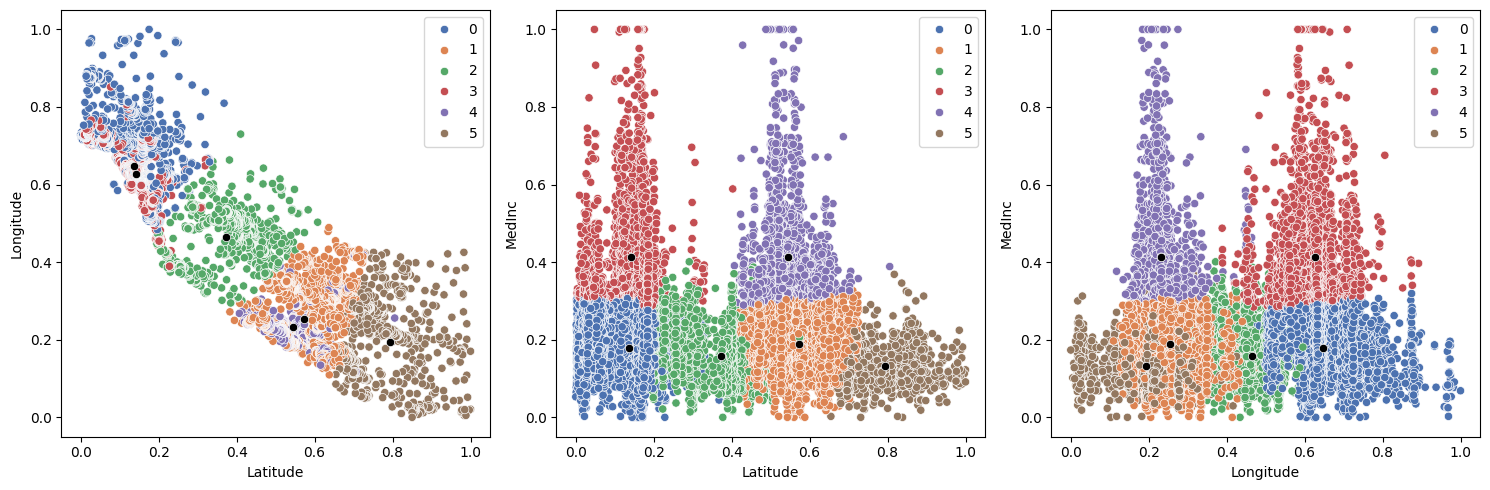

In [18]:
# Drawing the new clustering results
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = data_scaled      , x = "Latitude" , y = "Longitude", hue   = y_pred_scaled, palette = "deep")
sns.scatterplot(ax = axis[0], data = centroids_scaled , x = "Latitude" , y = "Longitude", color = "black"      , marker  = "o")

sns.scatterplot(ax = axis[1], data = data_scaled      , x = "Latitude" , y = "MedInc"   , hue   = y_pred_scaled, palette = "deep")
sns.scatterplot(ax = axis[1], data = centroids_scaled , x = "Latitude" , y = "MedInc"   , color = "black"      , marker  = "o")

sns.scatterplot(ax = axis[2], data = data_scaled      , x = "Longitude", y = "MedInc"   , hue   = y_pred_scaled, palette = "deep")
sns.scatterplot(ax = axis[2], data = centroids_scaled , x = "Longitude", y = "MedInc"   , color = "black"      , marker  = "o")
plt.tight_layout()

plt.show()

Now we have a pretty good cluster.

To determine the proper number of clusters we are going to use the Elbow Technique.

In [20]:
# Making the elbow plot
k_range = range(1, 11)
sse = []
for k in k_range:
    km = KMeans(n_clusters = k, n_init = "auto", random_state = 42)
    km.fit(data_scaled)
    sse.append(km.inertia_)
print(sse)

[2239.57597655464, 635.8458997864873, 540.3526477277734, 420.59256880824597, 335.09491393225414, 294.69881838716026, 256.10845437732445, 231.7850457413028, 220.02075092877521, 183.85868544548774]


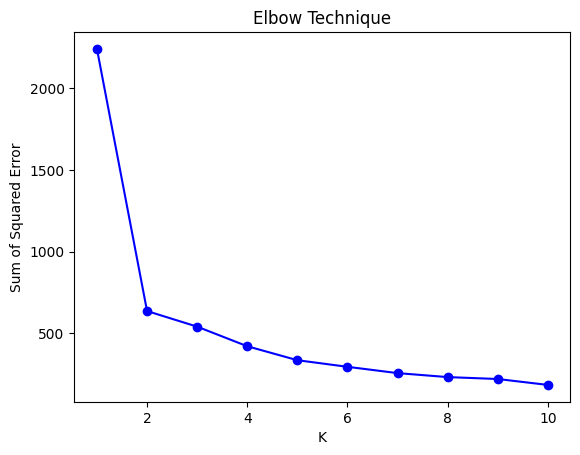

In [21]:
# Create the line chart
plt.plot(k_range, sse, marker="o", linestyle="-", color="blue")
# Customize the chart
plt.title("Elbow Technique")
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
# Display the chart
plt.show()

According to the graph the correct number of clusters are two, now we are going to use the K-Means algorithm once again with just two clusters.

In [23]:
X = data_scaled
X.head()

,MedInc,Latitude,Longitude
0,0.539668,0.567481,0.211155
1,0.538027,0.565356,0.212151
2,0.466028,0.564293,0.210159
3,0.354699,0.564293,0.209163
4,0.230776,0.564293,0.209163


In [24]:
km = KMeans(n_clusters = 2, n_init = "auto", random_state = 42)
km.fit(X)
predictions=km.predict(X)

In [25]:
new_centroids=pd.DataFrame(km.cluster_centers_)
new_centroids.columns = ["MedInc", "Latitude", "Longitude"]
new_centroids

,MedInc,Latitude,Longitude
0,0.235976,0.148814,0.631437
1,0.227629,0.576011,0.262337


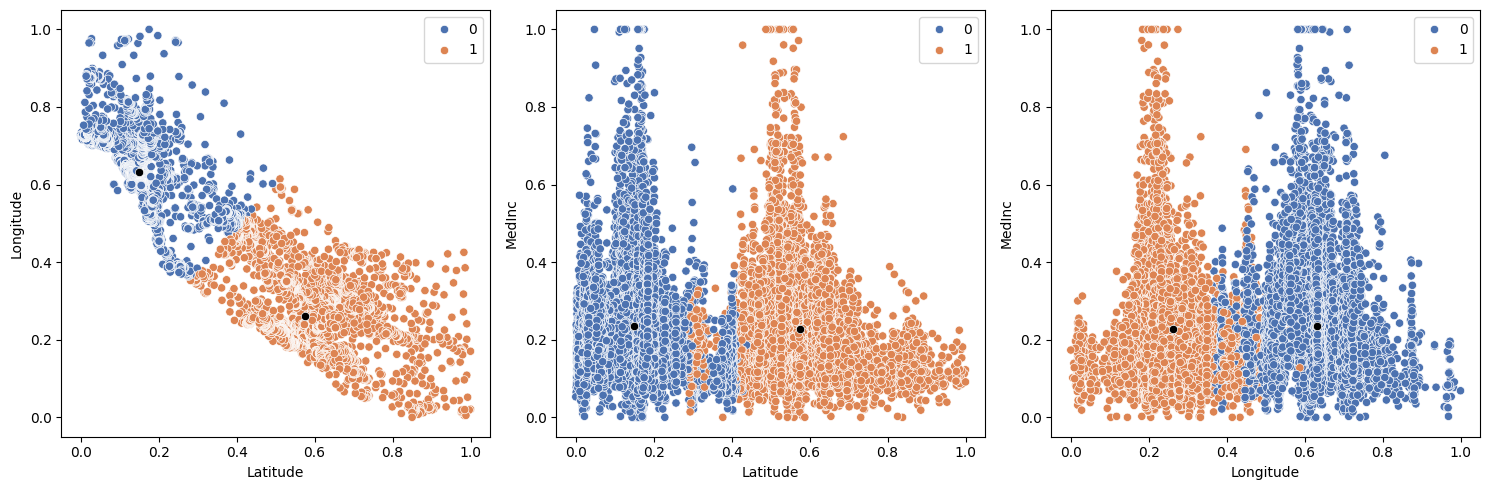

In [26]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X             , x = "Latitude" , y = "Longitude", hue   = predictions, palette = "deep")
sns.scatterplot(ax = axis[0], data = new_centroids , x = "Latitude" , y = "Longitude", color = "black"    , marker  = "o")

sns.scatterplot(ax = axis[1], data = X             , x = "Latitude" , y = "MedInc"   , hue   = predictions, palette = "deep")
sns.scatterplot(ax = axis[1], data = new_centroids , x = "Latitude" , y = "MedInc"   , color = "black"    , marker  = "o")

sns.scatterplot(ax = axis[2], data = X             , x = "Longitude", y = "MedInc"   , hue   = predictions, palette = "deep")
sns.scatterplot(ax = axis[2], data = new_centroids , x = "Longitude", y = "MedInc"   , color = "black"    , marker  = "o")
plt.tight_layout()

plt.show()